In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [6]:
data = pd.read_csv('data/campeonato-brasileiro-full.csv')
data['ano'] = pd.to_datetime(data['data']).dt.year
data = data.drop(columns=['formacao_mandante', 'formacao_visitante', 
                          'visitante_Estado', 'mandante_Estado', 
                          'hora', 'arena', 'data'])

def gols_para_classe(g):
    return min(g, 5)

data['mandante_Placar'] = data['mandante_Placar'].apply(gols_para_classe)
data['visitante_Placar'] = data['visitante_Placar'].apply(gols_para_classe)
                          

data['vencedor'] = data.apply(
    lambda row: 1 if row['vencedor'] == row['mandante'] 
                else 2 if row['vencedor'] == row['visitante']
                else 0,
    axis=1
)

le = LabelEncoder()

data['mandante'] = le.fit_transform(data['mandante'])
data['visitante'] = le.transform(data['visitante'])

data.head()

C:\Users\cailu\AppData\Local\Temp\ipykernel_18016\463044550.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['ano'] = pd.to_datetime(data['data']).dt.year


,ID,rodata,mandante,visitante,tecnico_mandante,tecnico_visitante,vencedor,mandante_Placar,visitante_Placar,ano
0,1,1,26,43,NaN,NaN,1,4,2,2003
1,2,1,2,24,NaN,NaN,1,2,0,2003
2,3,1,20,15,NaN,NaN,0,1,1,2003
3,4,1,23,34,NaN,NaN,0,2,2,2003
4,5,1,27,35,NaN,NaN,0,1,1,2003


In [7]:
def calcula_momentum(df, time_id, rodada_atual, col_time, N):
    historico = df[
        (((df['mandante'] == time_id) | (df['visitante'] == time_id)) &
         (df['rodata'] < rodada_atual))
    ].sort_values(by='rodata', ascending=False).head(N)

    vit = 0
    gols_marcados = 0
    gols_sofridos = 0

    for _, row in historico.iterrows():
        if row['mandante'] == time_id:
            # Resultado do jogo
            if row['vencedor'] == 1:
                vit += 1
            elif row['vencedor'] == 2:
                vit -= 1
            gols_marcados += row['mandante_Placar']
            gols_sofridos += row['visitante_Placar']
        elif row['visitante'] == time_id:
            if row['vencedor'] == 2:
                vit += 1
            elif row['vencedor'] == 1:
                vit -= 1
            gols_marcados += row['visitante_Placar']
            gols_sofridos += row['mandante_Placar']
    
    return vit, gols_marcados, gols_sofridos


In [8]:
def desempenho_em_relacao_a_media(df, time_id, rodada_atual, col_time, col_gols, N=5, tolerancia=0.3):
    # Etapa 1: pega as N últimas rodadas anteriores
    rodadas_anteriores = df[df['rodata'] < rodada_atual]['rodata'].drop_duplicates().sort_values(ascending=False).head(N)
    
    if rodadas_anteriores.empty:
        return 0  # início do campeonato

    # Etapa 2: filtra os jogos dessas rodadas
    historico_geral = df[df['rodata'].isin(rodadas_anteriores)]

    # Etapa 3: calcula a média geral de gols por time (mandante + visitante)
    total_gols = historico_geral['mandante_Placar'].sum() + historico_geral['visitante_Placar'].sum()
    total_times = len(historico_geral) * 2  # dois times por jogo

    if total_times == 0:
        return 0

    media_geral = total_gols / total_times

    # Etapa 4: gols do time no jogo atual
    jogo_atual = df[
        (df['rodata'] == rodada_atual) &
        ((df['mandante'] == time_id) | (df['visitante'] == time_id))
    ]

    if jogo_atual.empty:
        return 0

    row = jogo_atual.iloc[0]
    gols_jogo = row['mandante_Placar'] if row['mandante'] == time_id else row['visitante_Placar']

    # Etapa 5: comparação com média geral
    if gols_jogo > media_geral + tolerancia:
        return 1
    elif gols_jogo < media_geral - tolerancia:
        return -1
    else:
        return 0


In [9]:
N = 10
tolerancia = 0.3
momentum_vit_mandante = []
momentum_vit_visitante = []
prob_gol_mandante = []
prob_gol_visitante = []
momentum_dif = []
desempenho_mandante = []
desempenho_visitante = []

for idx, row in data.iterrows():
    time_mandante = row['mandante']
    time_visitante = row['visitante']
    rodada = row['rodata']
    
    vit_m, gols_marcados_m, gols_sofridos_m = calcula_momentum(data, time_mandante, rodada, 'mandante', N)
    vit_v, gols_marcados_v, gols_sofridos_v = calcula_momentum(data, time_visitante, rodada, 'visitante', N)

    desempenho_m = desempenho_em_relacao_a_media(data, time_mandante, rodada, 'mandante', 'mandante_Placar', N, tolerancia)
    desempenho_v = desempenho_em_relacao_a_media(data, time_visitante, rodada, 'visitante', 'visitante_Placar', N, tolerancia)

    desempenho_mandante.append(desempenho_m)
    desempenho_visitante.append(desempenho_v)
    
    momentum_dif.append(vit_m - vit_v)
    prob_gol_mandante.append((gols_marcados_m * (1 + gols_sofridos_v))/N if gols_sofridos_v != 0 else 0)
    prob_gol_visitante.append((gols_marcados_v * (1 + gols_sofridos_m))/N if gols_sofridos_m != 0 else 0)

data['momentum_dif'] = momentum_dif
data['momentum_prob_gol_mandante'] = prob_gol_mandante
data['momentum_prob_gol_visitante'] = prob_gol_visitante
data['desempenho_mandante'] = desempenho_mandante
data['desempenho_visitante'] = desempenho_visitante


In [10]:
# Etapa 1: Pontos por jogo
data['pontos_mandante_jogo'] = data['vencedor'].apply(lambda x: 3 if x == 1 else (1 if x == 0 else 0))
data['pontos_visitante_jogo'] = data['vencedor'].apply(lambda x: 3 if x == 2 else (1 if x == 0 else 0))

# Etapa 2: Pontos do ano anterior
# Pontos como mandante
pontos_ano_anterior_mandante = (
    data.groupby(['ano', 'mandante'])['pontos_mandante_jogo']
    .sum().groupby(level=1).shift(1).fillna(0)
).reset_index(name='pontos_ano_anterior_mandante')

# Pontos como visitante
pontos_ano_anterior_visitante = (
    data.groupby(['ano', 'visitante'])['pontos_visitante_jogo']
    .sum().groupby(level=1).shift(1).fillna(0)
).reset_index(name='pontos_ano_anterior_visitante')

# Jogos do ano anterior
jogos_ano_anterior_mandante = (
    data.groupby(['ano', 'mandante']).size()
    .groupby(level=1).shift(1).fillna(0)
).reset_index(name='jogos_ano_anterior_mandante')

jogos_ano_anterior_visitante = (
    data.groupby(['ano', 'visitante']).size()
    .groupby(level=1).shift(1).fillna(0)
).reset_index(name='jogos_ano_anterior_visitante')

# Etapa 3: Acúmulo no ano atual
data['pontos_mandante_acumulado'] = data.groupby(['ano', 'mandante'])['pontos_mandante_jogo'].cumsum().shift(1).fillna(0)
data['pontos_visitante_acumulado'] = data.groupby(['ano', 'visitante'])['pontos_visitante_jogo'].cumsum().shift(1).fillna(0)

data['jogos_em_casa'] = data.groupby(['ano', 'mandante']).cumcount()
data['jogos_fora'] = data.groupby(['ano', 'visitante']).cumcount()

# Etapa 4: Merge com valores do ano anterior
data = data.merge(pontos_ano_anterior_mandante, on=['ano', 'mandante'], how='left')
data = data.merge(pontos_ano_anterior_visitante, on=['ano', 'visitante'], how='left')
data = data.merge(jogos_ano_anterior_mandante, on=['ano', 'mandante'], how='left')
data = data.merge(jogos_ano_anterior_visitante, on=['ano', 'visitante'], how='left')

# Substitui NaNs por 0
for col in ['pontos_ano_anterior_mandante', 'pontos_ano_anterior_visitante',
            'jogos_ano_anterior_mandante', 'jogos_ano_anterior_visitante']:
    data[col] = data[col].fillna(0)

# Etapa 5: Aproveitamento = pontos / (jogos * 3)
data['total_pontos_mandante'] = data['pontos_mandante_acumulado'] + data['pontos_ano_anterior_mandante']
data['total_pontos_visitante'] = data['pontos_visitante_acumulado'] + data['pontos_ano_anterior_visitante']
data['total_jogos_mandante'] = data['jogos_em_casa'] + data['jogos_ano_anterior_mandante']
data['total_jogos_visitante'] = data['jogos_fora'] + data['jogos_ano_anterior_visitante']

# Evita divisão por zero
data['total_jogos_mandante'].replace(0, 1, inplace=True)
data['total_jogos_visitante'].replace(0, 1, inplace=True)

data['aproveitamento_mandante'] = data['total_pontos_mandante'] / (data['total_jogos_mandante'] )
data['aproveitamento_visitante'] = data['total_pontos_visitante'] / (data['total_jogos_visitante'] )

# Etapa 6: Diferença
data['dif_aproveitamento'] = data['aproveitamento_mandante'] - data['aproveitamento_visitante']

# Etapa 7: Limpeza
data.drop(columns=[
    'pontos_mandante_jogo', 'pontos_visitante_jogo',
    'pontos_mandante_acumulado', 'pontos_visitante_acumulado',
    'jogos_em_casa', 'jogos_fora',
    'pontos_ano_anterior_mandante', 'pontos_ano_anterior_visitante',
    'jogos_ano_anterior_mandante', 'jogos_ano_anterior_visitante',
    'total_pontos_mandante', 'total_pontos_visitante',
    'total_jogos_mandante', 'total_jogos_visitante',
    'aproveitamento_mandante', 'aproveitamento_visitante'
], inplace=True)



C:\Users\cailu\AppData\Local\Temp\ipykernel_18016\3623871148.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['total_jogos_mandante'].replace(0, 1, inplace=True)
C:\Users\cailu\AppData\Local\Temp\ipykernel_18016\3623871148.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [11]:
# Garante que a coluna 'ano' existe
if 'ano' not in data.columns:
    from datetime import datetime
    data_original = pd.read_csv("data/campeonato-brasileiro-full.csv")
    data['ano'] = pd.to_datetime(data_original['data']).dt.year

# 1. Gols do ano anterior (totais)
gols_ano_anterior_mandante = (
    data.groupby(['ano', 'mandante'])['mandante_Placar'].sum()
    .groupby(level=1).shift(1).reset_index(name='gols_ano_anterior')
)
gols_ano_anterior_visitante = (
    data.groupby(['ano', 'visitante'])['visitante_Placar'].sum()
    .groupby(level=1).shift(1).reset_index(name='gols_ano_anterior')
)
gols_sofridos_anterior_mandante = (
    data.groupby(['ano', 'mandante'])['visitante_Placar'].sum()
    .groupby(level=1).shift(1).reset_index(name='gols_sofridos_ano_anterior')
)
gols_sofridos_anterior_visitante = (
    data.groupby(['ano', 'visitante'])['mandante_Placar'].sum()
    .groupby(level=1).shift(1).reset_index(name='gols_sofridos_ano_anterior')
)

# 2. Acumulados até a rodada atual (sem contar o jogo atual)
data['gols_mandante_acumulado_ano'] = (
    data.groupby(['ano', 'mandante'])['mandante_Placar'].cumsum().shift(1).fillna(0)
)
data['gols_visitante_acumulado_ano'] = (
    data.groupby(['ano', 'visitante'])['visitante_Placar'].cumsum().shift(1).fillna(0)
)
data['gols_sofridos_mandante_ano'] = (
    data.groupby(['ano', 'mandante'])['visitante_Placar'].cumsum().shift(1).fillna(0)
)
data['gols_sofridos_visitante_ano'] = (
    data.groupby(['ano', 'visitante'])['mandante_Placar'].cumsum().shift(1).fillna(0)
)

# 3. Merge com gols do ano anterior
data = data.merge(gols_ano_anterior_mandante, on=['ano', 'mandante'], how='left')
data = data.merge(gols_ano_anterior_visitante, on=['ano', 'visitante'], how='left', suffixes=('', '_visitante'))
data = data.merge(gols_sofridos_anterior_mandante, on=['ano', 'mandante'], how='left')
data = data.merge(gols_sofridos_anterior_visitante, on=['ano', 'visitante'], how='left', suffixes=('', '_visitante'))

# 4. Soma dos anos: atual + anterior
data['gols_mandante_acumulado'] = data['gols_mandante_acumulado_ano'] + data['gols_ano_anterior'].fillna(0)
data['gols_visitante_acumulado'] = data['gols_visitante_acumulado_ano'] + data['gols_ano_anterior_visitante'].fillna(0)

data['gols_sofridos_mandante'] = data['gols_sofridos_mandante_ano'] + data['gols_sofridos_ano_anterior'].fillna(0)
data['gols_sofridos_visitante'] = data['gols_sofridos_visitante_ano'] + data['gols_sofridos_ano_anterior_visitante'].fillna(0)

data['dif_gols_mandante'] = data['gols_mandante_acumulado'] * ( 1 + data['gols_sofridos_visitante'] )
data['dif_gols_visitante'] = data['gols_visitante_acumulado'] * ( 1 + data['gols_sofridos_mandante'] )

# 5. Drop das colunas intermediárias se quiser
data.drop(columns=[
    'gols_mandante_acumulado_ano', 'gols_visitante_acumulado_ano',
    'gols_sofridos_mandante_ano', 'gols_sofridos_visitante_ano',
    'gols_ano_anterior', 'gols_ano_anterior_visitante',
    'gols_sofridos_ano_anterior', 'gols_sofridos_ano_anterior_visitante',
    'gols_mandante_acumulado', 'gols_visitante_acumulado',
    'gols_sofridos_mandante', 'gols_sofridos_visitante',
], inplace=True)


In [12]:
def contar_jogos_tecnico(df, col_time, col_tecnico, col_saida):
    contagem_por_jogo = []
    historico_por_time = {}

    for idx, row in df.iterrows():
        time = row[col_time]
        tecnico = row[col_tecnico]

        if time not in historico_por_time:
            historico_por_time[time] = {'tecnico_anterior': tecnico, 'contagem': 1}
        else:
            registro = historico_por_time[time]
            if tecnico == registro['tecnico_anterior']:
                registro['contagem'] += 1
            else:
                registro['contagem'] = 1
                registro['tecnico_anterior'] = tecnico

        contagem_por_jogo.append(historico_por_time[time]['contagem'])

    df[col_saida] = contagem_por_jogo

    return df


data_m = contar_jogos_tecnico(data, 'mandante', 'tecnico_mandante', 'tecnico_mandante_contagem')
data_v = contar_jogos_tecnico(data, 'visitante', 'tecnico_visitante', 'tecnico_visitante_contagem')

# Agora combinamos os resultados de volta com base nos índices originais
data['tecnico_mandante_contagem'] = data_m['tecnico_mandante_contagem']
data['tecnico_visitante_contagem'] = data_v['tecnico_visitante_contagem']

In [13]:
data.tail()

,ID,rodata,mandante,visitante,tecnico_mandante,tecnico_visitante,vencedor,mandante_Placar,visitante_Placar,ano,momentum_dif,momentum_prob_gol_mandante,momentum_prob_gol_visitante,desempenho_mandante,desempenho_visitante,dif_aproveitamento,dif_gols_mandante,dif_gols_visitante,tecnico_mandante_contagem,tecnico_visitante_contagem
8400,8401,38,6,4,R. Ceni,L. Scolari,1,4,1,2023,1,30.0,25.2,1,1,-0.081725,2009.0,2205.0,8,8
8401,8402,38,18,2,A. Cardoso de Oliveira,W. Carvalho,1,3,0,2023,-3,6.3,15.6,0,0,0.162162,2208.0,1517.0,11,14
8402,8403,38,39,22,M. Fernandes,J. Vojvoda,2,1,2,2023,-1,16.9,18.2,1,0,0.243243,2601.0,1680.0,7,32
8403,8404,38,41,20,D. Silvestre Júnior,A. Bacchi,1,1,0,2023,1,13.0,14.3,1,-1,0.216216,2842.0,2000.0,8,5
8404,8405,38,43,9,R. Díaz,P. Faria Caixinha,1,2,1,2023,2,17.1,9.9,0,0,0.923423,2356.0,1050.0,12,19


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from sklearn.utils import compute_class_weight
import matplotlib.pyplot as plt
from sklearn.multioutput import MultiOutputClassifier
import seaborn as sns
from sklearn.dummy import DummyClassifier


In [15]:
# Remove infs e NaNs de forma robusta
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.fillna(0, inplace=True)

# Agora garanta que todas as colunas estão numéricas
data = data.apply(pd.to_numeric, errors='coerce')

In [16]:
# Features específicas para cada modelo
features_mandante = [
    'momentum_dif',
    'dif_gols_mandante',
    'dif_aproveitamento',
    'momentum_prob_gol_mandante',
    'desempenho_mandante',
    'tecnico_mandante_contagem',
    'tecnico_visitante_contagem',
]

features_visitante = [
    'momentum_dif',
    'dif_gols_visitante',
    'dif_aproveitamento',
    'momentum_prob_gol_visitante',
    'desempenho_visitante',
    'tecnico_visitante_contagem',
    'tecnico_mandante_contagem',
]

# Targets
target_mandante = 'mandante_Placar'
target_visitante = 'visitante_Placar'

# Remove first year (2003) to avoid bias
data = data[data['ano'] != 2003].copy()

# Inputs e targets
X_m = data[features_mandante]
X_v = data[features_visitante]
y = data[[target_mandante, target_visitante]]

# Split (garantindo consistência)
X_m_train, X_m_test, y_train, y_test = train_test_split(X_m, y, test_size=0.2, random_state=42)
X_v_train, X_v_test = X_v.loc[X_m_train.index], X_v.loc[X_m_test.index]

In [17]:
# Class weights
classes_m = np.unique(y_train[target_mandante])
classes_v = np.unique(y_train[target_visitante])

weights_m_values = compute_class_weight('balanced', classes=classes_m, y=y_train[target_mandante])
weights_v_values = compute_class_weight('balanced', classes=classes_v, y=y_train[target_visitante])

class_weights_m = dict(zip(classes_m, weights_m_values))
class_weights_v = dict(zip(classes_v, weights_v_values))

weights_m = y_train[target_mandante].map(class_weights_m)
weights_v = y_train[target_visitante].map(class_weights_v)

# Modelos
xgb_m = XGBClassifier(
    num_class=6,
    objective='multi:softprob',
    eval_metric='mlogloss',
    learning_rate=0.05,
    max_depth=6,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20,
    random_state=42
)

xgb_v = XGBClassifier(
    num_class=6,
    objective='multi:softprob',
    eval_metric='mlogloss',
    learning_rate=0.05,
    max_depth=6,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20,
    random_state=42
)

# Treinamento
xgb_m.fit(X_m_train, y_train[target_mandante], sample_weight=weights_m, eval_set=[(X_m_test, y_test[target_mandante])], verbose=False)
xgb_v.fit(X_v_train, y_train[target_visitante], sample_weight=weights_v, eval_set=[(X_v_test, y_test[target_visitante])], verbose=False)

# Multi-modelo manual (apenas para agrupamento)
multi_model = MultiOutputClassifier(estimator=xgb_m)
multi_model.estimators_ = [xgb_m, xgb_v]

In [18]:
dummy_m = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_m.fit(X_m_train, y_train[target_mandante])
y_dummy_m_pred = dummy_m.predict(X_m_test)

print("📊 Dummy - Mandante (Most Frequent)")
print(classification_report(y_test[target_mandante], y_dummy_m_pred, digits=4))

dummy_v = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_v.fit(X_v_train, y_train[target_visitante])
y_dummy_v_pred = dummy_v.predict(X_v_test)

print("📊 Dummy - Visitante (Most Frequent)")
print(classification_report(y_test[target_visitante], y_dummy_v_pred, digits=4))

📊 Dummy - Mandante (Most Frequent)
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       328
           1     0.3514    1.0000    0.5200       552
           2     0.0000    0.0000    0.0000       388
           3     0.0000    0.0000    0.0000       191
           4     0.0000    0.0000    0.0000        85
           5     0.0000    0.0000    0.0000        27

    accuracy                         0.3514      1571
   macro avg     0.0586    0.1667    0.0867      1571
weighted avg     0.1235    0.3514    0.1827      1571

📊 Dummy - Visitante (Most Frequent)
              precision    recall  f1-score   support

           0     0.3641    1.0000    0.5338       572
           1     0.0000    0.0000    0.0000       578
           2     0.0000    0.0000    0.0000       287
           3     0.0000    0.0000    0.0000        89
           4     0.0000    0.0000    0.0000        38
           5     0.0000    0.0000    0.0000         7

    ac

C:\Users\cailu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\cailu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\cailu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classificati

In [19]:
# Previsão com probabilidade por classe
y_pred_proba_mandante = xgb_m.predict_proba(X_m_test)
y_pred_proba_visitante = xgb_v.predict_proba(X_v_test)

# Classe com maior probabilidade
y_pred_mandante = np.argmax(y_pred_proba_mandante, axis=1)
y_pred_visitante = np.argmax(y_pred_proba_visitante, axis=1)

# Valores reais
y_test_mandante = y_test[target_mandante]
y_test_visitante = y_test[target_visitante]

# Avaliação
print("Mandante:")
print(classification_report(y_test_mandante, y_pred_mandante, digits=4))

print("Visitante:")
print(classification_report(y_test_visitante, y_pred_visitante, digits=4))


Mandante:
              precision    recall  f1-score   support

           0     0.2448    0.2134    0.2280       328
           1     0.3378    0.2736    0.3023       552
           2     0.2575    0.2216    0.2382       388
           3     0.1283    0.1780    0.1491       191
           4     0.0568    0.1176    0.0766        85
           5     0.0159    0.0370    0.0222        27

    accuracy                         0.2241      1571
   macro avg     0.1735    0.1736    0.1694      1571
weighted avg     0.2523    0.2241    0.2353      1571

Visitante:
              precision    recall  f1-score   support

           0     0.4313    0.3899    0.4096       572
           1     0.3984    0.3529    0.3743       578
           2     0.2247    0.2787    0.2488       287
           3     0.0764    0.1236    0.0944        89
           4     0.0526    0.0526    0.0526        38
           5     0.0000    0.0000    0.0000         7

    accuracy                         0.3310      1571
  

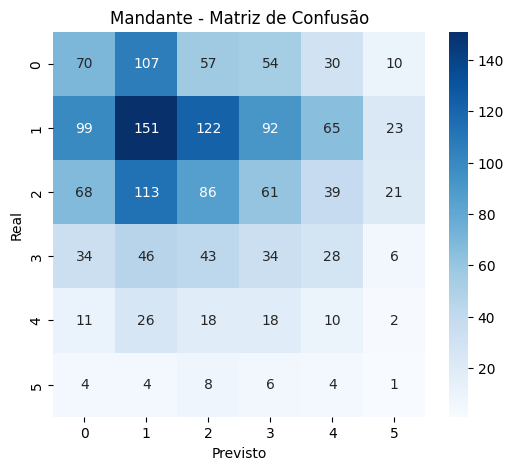

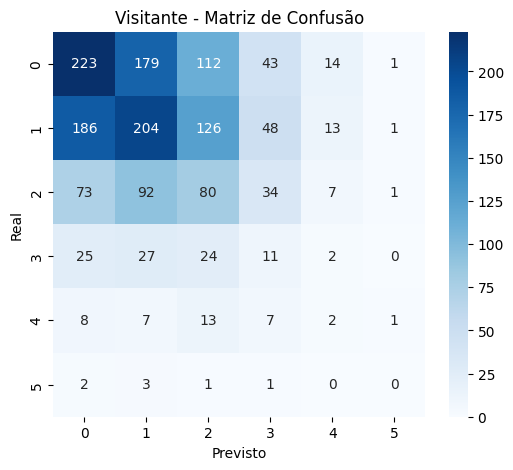

In [20]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.show()

plot_confusion(y_test_mandante, y_pred_mandante, "Mandante - Matriz de Confusão")
plot_confusion(y_test_visitante, y_pred_visitante, "Visitante - Matriz de Confusão")


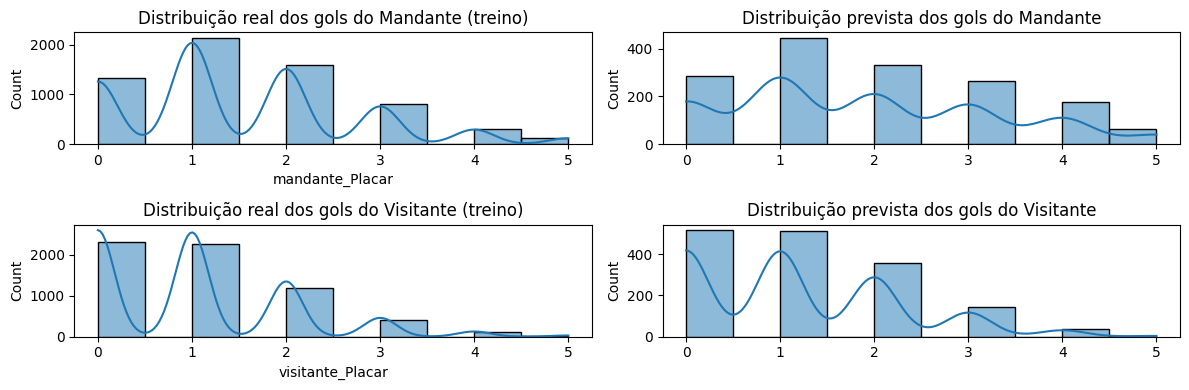

In [21]:
plt.figure(figsize=(12,4))

plt.subplot(2, 2, 1)
sns.histplot(y_train.iloc[:,0], bins=10, kde=True)
plt.title("Distribuição real dos gols do Mandante (treino)")

plt.subplot(2, 2, 2)
sns.histplot(y_pred_mandante, bins=10, kde=True)
plt.title("Distribuição prevista dos gols do Mandante")

plt.subplot(2, 2, 3)
sns.histplot(y_train.iloc[:,1], bins=10, kde=True)
plt.title("Distribuição real dos gols do Visitante (treino)")

plt.subplot(2, 2, 4)
sns.histplot(y_pred_visitante, bins=10, kde=True)
plt.title("Distribuição prevista dos gols do Visitante")

plt.tight_layout()
plt.show()

In [22]:
def resultado_previsto(gols_m, gols_v):
    if gols_m < gols_v:
        return 2  
    elif gols_m > gols_v:
        return 1
    else:
        return 0

# Aplica a função em cada linha
resultado_predito = [resultado_previsto(m, v) for m, v in zip(y_pred_mandante, y_pred_visitante)]

# Extraindo os rótulos corretos para o teste
y_real_vencedor = data.loc[y_test.iloc[:,0].index, 'vencedor']

In [23]:
acc = accuracy_score(y_real_vencedor, resultado_predito)
print("Accuracy da predição do resultado (vitória/empate/derrota):", round(acc * 100, 2), "%")

Accuracy da predição do resultado (vitória/empate/derrota): 40.29 %


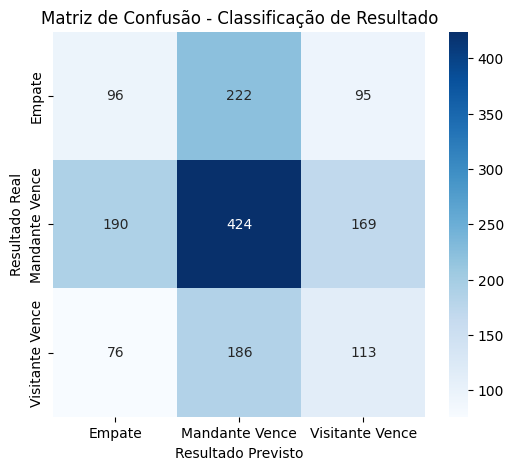

                 precision    recall  f1-score   support

         Empate       0.27      0.23      0.25       413
 Mandante Vence       0.51      0.54      0.53       783
Visitante Vence       0.30      0.30      0.30       375

       accuracy                           0.40      1571
      macro avg       0.36      0.36      0.36      1571
   weighted avg       0.40      0.40      0.40      1571



In [24]:
# Confusion matrix
cm = confusion_matrix(y_real_vencedor, resultado_predito)
labels = ['Empate', 'Mandante Vence', 'Visitante Vence']

# Usando seaborn para visualização
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Resultado Previsto")
plt.ylabel("Resultado Real")
plt.title("Matriz de Confusão - Classificação de Resultado")
plt.show()

# Relatório completo
print(classification_report(y_real_vencedor, resultado_predito, target_names=labels))


In [25]:
def extract_features(N, tol, meanTotal,
                     winNm, lossNm, goalsNm, goalsAgainstNm, gamesm, pointsLastm, pointsm, golsLastm, golsAgaintsLastm, golsNm, golsAgainstNm, tecM,
                     winNv, lossNv, goalsNv, goalsAgainstNv, gamesv, pointsLastv, pointsv, golsLastv, golsAgaintsLastv, golsNv, golsAgainstNv, tecV):
    
    pointsNm = winNm - lossNm
    meanGoalsNm = goalsNm/N
    flowm = 0
    if meanGoalsNm > meanTotal + tol:
        flowm = 1
    elif meanGoalsNm < meanTotal - tol:
        flowm = -1
    else:
        flowm = 0
    
    pointsNv = winNv - lossNv
    meanGoalsNv = goalsNv/N
    flowv = 0
    if meanGoalsNv > meanTotal + tol:
        flowv = 1
    elif meanGoalsNv < meanTotal - tol:
        flowv = -1
    else:
        flowv = 0

    prob_m = goalsNm * (1 + goalsAgainstNv) / N
    prob_v = goalsNv * (1 + goalsAgainstNm) / N 

    aprov_m = (pointsLastm + pointsm) / (38 + gamesm)
    aprov_v = (pointsLastv + pointsv) / (38 + gamesv)
    dif_aproveitamento = aprov_m - aprov_v

    gols_mandante = (golsLastm + golsNm) * (1 + golsAgaintsLastv + golsAgainstNv)
    gols_visitante = (golsLastv + golsNv) * (1 + golsAgaintsLastm + golsAgainstNm)

    return {"desempenho_mandante" : flowm, 
            "desempenho_visitante": flowv, 
            "momentum_dif": pointsNm-pointsNv, 
            "momentum_prob_gol_mandante" : prob_m,
            "momentum_prob_gol_visitante": prob_v,
            "dif_aproveitamento" : dif_aproveitamento,
            "dif_gols_mandante" : gols_mandante,
            "dif_gols_visitante" : gols_visitante,
            'tecnico_mandante_contagem' : tecM,
            'tecnico_visitante_contagem' : tecV,
    }

In [26]:
import json

with open("teams.json", "r") as f:
    dados = json.load(f)

In [27]:
meanTotal = 0.8

In [28]:
def prever_jogo(mandante: str, visitante: str,
                dados: dict,
                modelo_m, modelo_v,
                features_mandante: list,
                features_visitante: list,
                N=5, tol=0.3, meanTotal=1):

    time_m = dados[mandante]
    time_v = dados[visitante]

    # Extrai todas as features disponíveis
    features = extract_features(
        N, tol, meanTotal,
        winNm=time_m["vitoriasN"], lossNm=time_m["derrotasN"],
        goalsNm=time_m["golsN"], goalsAgainstNm=time_m["golsContraN"],
        gamesm=time_m["jogosTemporada"], pointsLastm=time_m["pontosUltimaTemporada"], 
        pointsm=time_m["pontosTemporada"],
        golsLastm=time_m["golsMarcadosUltimaTemporada"], golsAgaintsLastm=time_m["golsSofridosUltimaTemporada"],
        golsNm=time_m["golsMarcadosTemporada"], golsAgainstNm=time_m["golsSofridosTemporada"],
        tecM=time_m["partidasTecnico"],

        winNv=time_v["vitoriasN"], lossNv=time_v["derrotasN"],
        goalsNv=time_v["golsN"], goalsAgainstNv=time_v["golsContraN"],
        gamesv=time_v["jogosTemporada"], pointsLastv=time_v["pontosUltimaTemporada"], 
        pointsv=time_v["pontosTemporada"],
        golsLastv=time_v["golsMarcadosUltimaTemporada"], golsAgaintsLastv=time_v["golsSofridosUltimaTemporada"],
        golsNv=time_v["golsMarcadosTemporada"], golsAgainstNv=time_v["golsSofridosTemporada"],
        tecV=time_v["partidasTecnico"]
    )

    # Cria os dataframes com apenas as colunas usadas em cada modelo
    X_m = pd.DataFrame([features])[features_mandante]
    X_v = pd.DataFrame([features])[features_visitante]

    # Previsão via predict_proba → argmax da classe com maior probabilidade
    y_pred_m = np.argmax(modelo_m.predict_proba(X_m), axis=1)[0]
    y_pred_v = np.argmax(modelo_v.predict_proba(X_v), axis=1)[0]

    return {
        "mandante": mandante,
        "visitante": visitante,
        "placar": f"{y_pred_m} x {y_pred_v}",
        "gols_mandante": y_pred_m,
        "gols_visitante": y_pred_v
    }


In [29]:
time1 = "SaoPaulo"
time2 = "Sport"

In [30]:
resultado = prever_jogo(
    mandante=time1,
    visitante=time2,
    dados=dados,
    features_mandante=features_mandante,
    features_visitante=features_visitante,
    modelo_m=xgb_m,
    modelo_v=xgb_v,
    N=N,
    tol=tolerancia,
    meanTotal=0.8 
)

print(f"Placar previsto: {resultado['mandante']} {resultado['placar']} {resultado['visitante']}")

resultado = prever_jogo(
    mandante=time2,
    visitante=time1,
    dados=dados,
    features_mandante=features_mandante,
    features_visitante=features_visitante,
    modelo_m=xgb_m,
    modelo_v=xgb_v,
    N=N,
    tol=tolerancia,
    meanTotal=0.8 
)

print(f"Placar previsto: {resultado['mandante']} {resultado['placar']} {resultado['visitante']}")


Placar previsto: SaoPaulo 2 x 1 Sport
Placar previsto: Sport 0 x 1 SaoPaulo
